# Chapter 7 example problems from CRL Book
   

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import multiprocess as mp
from multiprocess import Process
from matplotlib.patches import FancyArrowPatch
import networkx as nx
import pandas as pd

from causal_gym.envs import MDPSCM, MDPPCH
import importlib

## MDP Example 7.4 (Causal-AI Book)
    
This notebook implements Example 7.4 from Chapter 7 of the Causal Reinforcement Learning book. This example focuses on the observational distribution of the MDP model, which represents an inventory control problem.

In Example 7.4, the observational distribution analysis is performed to show the inventory manager's policy generates an expected profit of 0.1 every day, leading to a discounted cumulative reward of 1.0 (with discount factor $\gamma = 0.9$).

Key components from the example:
- The inventory manager observes the current size of the inventory ($S_i$)
- Manager decides whether to purchase new items to fill the inventory ($X_i$)
- Manager receives profit ($Y_i$) by the end of day $i$
- The model includes human errors, demand uncertainties, and monetary values as exogenous variables
- The behavioral policy leads to a modest daily profit

We'll implement this example and verify the expected profit matches the theoretical value from the book
   

In [2]:
# Discount factor from Example 7.4
GAMMA = 0.9

# Number of samples for each experiment
N_SAMPLES = 10000

# Maximum number of steps per episode
MAX_STEPS = 1000

## Helper Function for Running Episodes

First, we'll create a helper function to run episodes in our MDP environment:

In [3]:
def run_episode(policy=None, seed=None, GAMMA=0.9, MAX_STEPS=10000):
    #Run a single episode in the MDP environment.
    

    # Initialize environment
    env = MDPPCH(max_step=MAX_STEPS)

    # Reset environment with seed
    s, _ = env.reset(seed=seed)
    
    # Track states, actions, rewards
    states = [s]
    actions = []
    rewards = []
    
    done = False
    discounted_reward = 0
    step = 0
    
    # Run episode
    while not done:
        if policy is None:
            # Use behavioral policy ('see' mode)
            s, y, _, done, info = env.see()
        else:
            # Use provided policy ('do' mode)
            s, y, _, done, info = env.do(policy)
        
        # Update tracking variables
        if policy is not None:
            actions.append(policy(states[-1]))
        else:
            actions.append(info['natural_action'])
        states.append(s)
        rewards.append(y)
        
        # Update discounted reward
        discounted_reward = discounted_reward * GAMMA + y
        
        step += 1
        if step >= MAX_STEPS:
            break
    
    return discounted_reward, states, actions, rewards

## Evaluating Observational Distribution (Example 7.4)
   

### Evaluating behavioral policy
From the exmaple, we see that with a behavioral policy that takes actions by $X_i \leftarrow S_i \oplus U_{i,1}$, at each time step, we can only achieve an expected reward of $$\tag{6}\mathbb{E}[Y_i|s_i, x_i] = 0.1$$

Thus, if we evaluate this behavioral policy for infinitely long, we would have a discounted cumulative reutrn of,
$$\tag{7}\mathbb{E}[\sum_{i=1}^\infty \gamma^{i-1}Y_i] = \frac{0.1}{1-\gamma}$$

In the following simulation, we use $\gamma = .9$ so we will see a cumulative return close to $\frac{0.1}{1- .9} = 1$.

Now, let's evaluate the observational distribution by running episodes with the behavioral policy:

In [4]:
# Calculate the observational distribution with the behavioral policy 
rewards_obs = []
daily_profits_obs = []
episode_lengths_obs = []

# Run episodes 
manager = mp.Manager()
results = manager.list()
processes = []

for i in range(N_SAMPLES):
    p = Process(target=lambda: results.append(run_episode(seed=i)))
    processes.append(p)
    p.start()

for p in tqdm(processes, desc="Running episodes with behavioral policy"):
    p.join()

# Process results
for result in results:
    discounted_reward, states, actions, rewards = result
    rewards_obs.append(discounted_reward)
    daily_profits_obs.extend(rewards)
    episode_lengths_obs.append(len(rewards))

# Calculate statistics
avg_reward_obs = np.mean(rewards_obs)
avg_daily_profit_obs = np.mean(daily_profits_obs)
avg_episode_length_obs = np.mean(episode_lengths_obs)

print("Observational Distribution Results (Example 7.4):")
print("----------------------------------------")
print(f"Average daily profit [Y_i]: {avg_daily_profit_obs:.4f} (Expected: 0.1)")
print(f"Average discounted cumulative reward: {avg_reward_obs:.4f} (Expected: 1.0)")
print(f"Average episode length: {avg_episode_length_obs:.1f} steps")

Process Process-1729:
Process Process-1727:
Process Process-1721:
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/opt/homebrew/anaconda3/envs/pmml/lib/python3.11/site-packages/multiprocess/managers.py", line 814, in _callmethod
    conn = self._tls.connection
           ^^^^^^^^^^^^^^^^^^^^
  File "/opt/homebrew/anaconda3/envs/pmml/lib/python3.11/site-packages/multiprocess/managers.py", line 814, in _callmethod
    conn = self._tls.connection
           ^^^^^^^^^^^^^^^^^^^^
  File "/opt/homebrew/anaconda3/envs/pmml/lib/python3.11/site-packages/multiprocess/managers.py", line 814, in _callmethod
    conn = self._tls.connection
           ^^^^^^^^^^^^^^^^^^^^
AttributeError: 'ForkAwareLocal' object has no attribute 'connection'
AttributeError: 'ForkAwareLocal' object has no attribute 'connection'
AttributeError: 'ForkAwareLocal' object has no attribute 'connection'

During handling of the above exception, another exception

Observational Distribution Results (Example 7.4):
----------------------------------------
Average daily profit [Y_i]: 0.1000 (Expected: 0.1)
Average discounted cumulative reward: 1.0041 (Expected: 1.0)
Average episode length: 10000.0 steps


This aligns with our predicted cumilitative rewards and daily profit that we calculated earlier

## Transition and Reward Matrix from Observational Data

We now consider the transition distribution $P(S_{i+1} | S_i, X_i)$ and expected reward $\mathbb{E}[Y_i | S_i, X_i]$

$$
\tag{8}
P(S_{i+1} | S_i = s_i,X_i = x_i) = P((s_i \vee x_i)\oplus U_{i,1} \oplus U_{i,2} | S_i = s_i,X_i = x_i)
$$

For $M_{MDP}^*$ observing events $S_i = 0,X_i = 0$ implies that $U_{i,1} = 0$, so:

$$
\tag{9}
P(S_{i+1} = 1 | S_i = 0,X_i = 0) = P((0 \vee 0)\oplus 0 \oplus 1 | S_i = 0,X_i = 0)\\
= P(U_{i,2} = 1)\\
= 0.1
$$

The second step holds since the stochastic demand $U_{i,2}$ is an independent factor only affecting
$S_{i+1}$. Similarly, evaluating the expected reward $Y_i$ in $M_{MDP}^*$ gives:

$$
\tag{10}
\mathbb{E}[Y_i | S_i, X_i] = \mathbb{E} [s_i \oplus x_i \oplus U_{i, 1} \oplus U_{i, 3} | S_i = s_i , X_i = x_i]
$$

Let's calculate the transition probability $P(S_{i+1} | S_i, X_i)$ and expected reward $\mathbb{E}[Y_i | S_i, X_i]$ from the observational data:

In [5]:
def generate_state_action_data(n_episodes=100):
    # Generate state-action-reward-next_state data from behavioral policy
    data = []
    
    for i in range(n_episodes):
        env = MDPPCH(max_step=MAX_STEPS)
        s, _ = env.reset(seed=i)
        done = False
        
        while not done:
            # Use behavioral policy
            next_s, r, _, done, info = env.see()
            data.append((s, info['natural_action'], r, next_s))
            s = next_s
            
            if len(data) > 10000:  # data size
                break
    
    return data

# generate data
state_action_data = generate_state_action_data(100)

# Create transition and reward matrices
# Format: [s, x] -> [s', r]
transition_counts = np.zeros((2, 2, 2))  # [s, x, s']
reward_sums = np.zeros((2, 2))  # [s, x]
counts = np.zeros((2, 2))  # [s, x]

for s, x, r, next_s in state_action_data:
    transition_counts[s, x, next_s] += 1
    reward_sums[s, x] += r
    counts[s, x] += 1

# Calculate transition probabilities and expected rewards
transition_probs = np.zeros((2, 2, 2))
expected_rewards = np.zeros((2, 2))

for s in range(2):
    for x in range(2):
        if counts[s, x] > 0:
            # P(S_{i+1} | S_i, X_i)
            for next_s in range(2):
                transition_probs[s, x, next_s] = transition_counts[s, x, next_s] / counts[s, x]
            
            # E[Y_i | S_i, X_i]
            expected_rewards[s, x] = reward_sums[s, x] / counts[s, x]

# Print transition probabilities and expected rewards
print("Transition Probabilities P(S_{i+1} | S_i, X_i):")
print("----------------------------------------")
for s in range(2):
    for x in range(2):
        for next_s in range(2):
            if counts[s, x] > 0:
                print(f"P(S_{i+1}={next_s} | S_i={s}, X_i={x}) = {transition_probs[s, x, next_s]:.4f}")

print("\\nExpected Rewards E[Y_i | S_i, X_i]:")
print("----------------------------------------")
for s in range(2):
    for x in range(2):
        if counts[s, x] > 0:
            print(f"E[Y_i | S_i={s}, X_i={x}] = {expected_rewards[s, x]:.4f}")

Transition Probabilities P(S_{i+1} | S_i, X_i):
----------------------------------------
P(S_10000=0 | S_i=0, X_i=0) = 0.0814
P(S_10000=1 | S_i=0, X_i=0) = 0.0814
P(S_10000=0 | S_i=0, X_i=1) = 0.0814
P(S_10000=1 | S_i=0, X_i=1) = 0.0814
P(S_10000=0 | S_i=1, X_i=0) = 0.5944
P(S_10000=1 | S_i=1, X_i=0) = 0.5944
P(S_10000=0 | S_i=1, X_i=1) = 0.8725
P(S_10000=1 | S_i=1, X_i=1) = 0.8725
\nExpected Rewards E[Y_i | S_i, X_i]:
----------------------------------------
E[Y_i | S_i=0, X_i=0] = 0.1047
E[Y_i | S_i=0, X_i=1] = 0.1048
E[Y_i | S_i=1, X_i=0] = 0.1329
E[Y_i | S_i=1, X_i=1] = 0.1373


## Visualize the Observational MDP as a Finite-State Machine

Let's create a visualization of the MDP as a finite-state machine, similar to Figure 7.5(b) in the book:

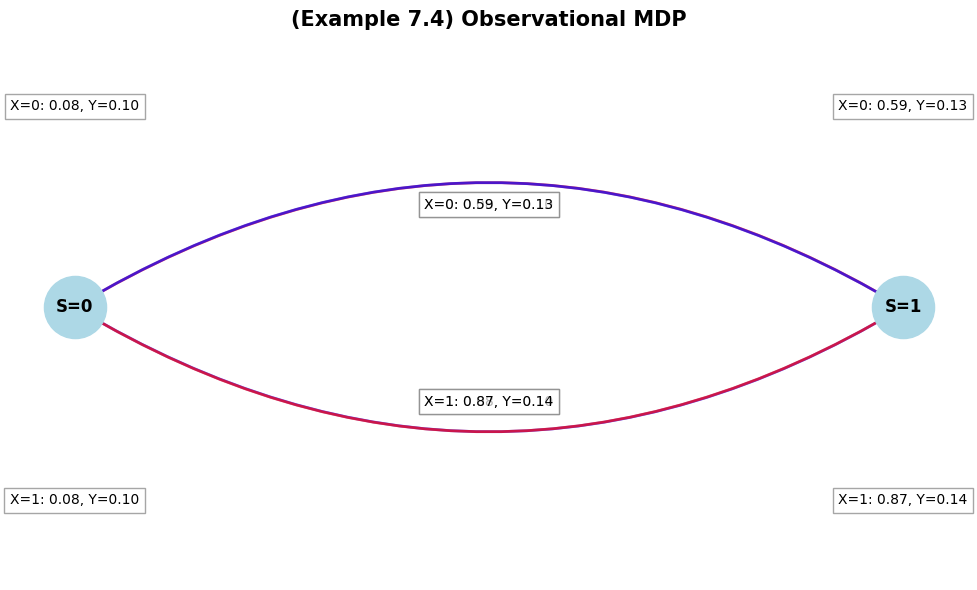

In [6]:
G = nx.DiGraph()

# nodes for states
G.add_node("S=0")
G.add_node("S=1")

plt.figure(figsize=(10, 6))

# positions for the nodes
pos = {"S=0": (0, 0), "S=1": (3, 0)}

nx.draw_networkx_nodes(G, pos, node_size=2000, node_color="lightblue")
nx.draw_networkx_labels(G, pos, font_size=12, font_weight="bold")

# Draw edges 
edge_labels = {}

# Helper function to create curved edges
def create_curved_edge(ax, pos1, pos2, rad, **kwargs):
    #  curved edge
    return FancyArrowPatch(
        pos1, pos2,
        connectionstyle=f'arc3,rad={rad}',
        arrowstyle='->,head_width=0.6,head_length=1',
        **kwargs
    )

#draw transitions
ax = plt.gca()

# For each state and action pair
for s in range(2):
    for x in range(2):
        if counts[s, x] > 0:
            pos_from = pos[f"S={s}"]
            
            for next_s in range(2):
                # Only draw if transition probability is significant
                if transition_probs[s, x, next_s] > 0.01:
                    # destination position
                    pos_to = pos[f"S={next_s}"]
                    
                    # curvature based on transition type
                    if s == next_s:  # Self-loop
                        rad = 0.5 if x == 0 else -0.5
                        offset_y = 0.3 if x == 0 else -0.3
                        
                        # Add self-loop
                        arrow = create_curved_edge(
                            ax, 
                            (pos_from[0], pos_from[1]+offset_y), 
                            (pos_from[0], pos_from[1]+offset_y),
                            rad,
                            color='blue' if x == 0 else 'red',
                            linewidth=2,
                            alpha=0.7
                        )
                        ax.add_patch(arrow)
                        
                        label_pos = (pos_from[0], pos_from[1] + (0.6 if x == 0 else -0.6))
                    else:  # transition to different state
                        rad = 0.3 if x == 0 else -0.3
                        
                        # Add arrow
                        arrow = create_curved_edge(
                            ax, 
                            pos_from, 
                            pos_to,
                            rad,
                            color='blue' if x == 0 else 'red',
                            linewidth=2,
                            alpha=0.7
                        )
                        ax.add_patch(arrow)
                        
                        mid_x = (pos_from[0] + pos_to[0]) / 2
                        mid_y = (pos_from[1] + pos_to[1]) / 2
                        label_pos = (mid_x, mid_y + (0.3 if x == 0 else -0.3))
                    
                    #  text label for transition probability and reward
                    plt.text(
                        label_pos[0], label_pos[1],
                        f"X={x}: {transition_probs[s, x, next_s]:.2f}, Y={expected_rewards[s, x]:.2f}",
                        horizontalalignment='center',
                        bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray')
                    )

plt.title("(Example 7.4) Observational MDP", fontsize=15, fontweight="bold")
plt.axis('off')
plt.tight_layout()
plt.show()

## Calculate Theoretical Value (For Verification)

Let's calculate the theoretical value as described in Example 7.4:

$$
\tag{11}
\mathbb{E} [\sum_{i=1}{\inf}\gamma^{i-1}Y_i] = \sum_{i=1}{\inf}\gamma^{i-1}\mathbb{E}[Y_i] = \frac{\mathbb{E}[Y_i]}{(1-\gamma)}
$$

In [7]:
# the expected profit is 0.1 per day
daily_profit = 0.1

# With discount factor 0.9, the expected cumulative reward is:
theoretical_cumulative_reward = daily_profit / (1 - GAMMA)

print(f"Theoretical daily profit: {daily_profit}")
print(f"Theoretical discounted cumulative reward: {theoretical_cumulative_reward}")

Theoretical daily profit: 0.1
Theoretical discounted cumulative reward: 1.0000000000000002


# Example 7.6

Recall the SCM from the original example 7.2:

$$
\tag{15}
\mathcal{M}_{\text{MDP}}^* = \langle \boldsymbol{U} = \{U_{i,1}, U_{i,2}, U_{i,3}\}, \boldsymbol{V} = \{X_i, Y_i, S_i\}, \mathcal{F} = \{\mathcal{F}_i\}, P(\boldsymbol{U})\rangle_{i=1,2,...}$$

$$
\tag{16}
\mathcal{F}_i=
\begin{cases}
S_i \gets (S_{i-1}\vee X_{i-1})\oplus U_{i-1, 1} \oplus U_{i-1, 2},\\
X_i \gets S_i \oplus U_{i,1},\\
Y_i \gets S_i \oplus X_i \oplus U_{i,1} \oplus U_{i,3}
\end{cases}$$



Key points from the example:
- The original MDP from Example 7.4 involves the inventory manager making decisions based on the current inventory state
- The submodel considers what happens when we force a specific inventory management policy
- This shows how interventions do(X₁=x₁, X₂=x₂, ...) create a new causal model where the mechanisms for X are replaced
- The calculation of expected profits in the submodel shows how different policies can lead to different outcomes

A policy p in the MDP model M is a sequence of decision rules p = (p1,p2,...), one for every time step i. Every decision rule pi(Xi | Si) is a conditional distribution mapping from the domain of state Si to action Xi, for every step i = 1,2,.... The submodel entailed by intervention do(X1 ⇠ p1(X1 | S1),X2 ⇠ p2(X2 | S2),...) is described by the tuple


$$
\tag{17}
\mathcal{M}_{\text{MDP}_\pi}^* = \langle \boldsymbol{U} = \{U_{i,1}, U_{i,2}, U_{i,3}\}, \boldsymbol{V} = \{X_i, Y_i, S_i\}, \mathcal{F}_\pi = \{\mathcal{F}_{\pi_{i}}, P(\boldsymbol{U})\rangle_{i=1,2,...}$$

where causal mechanisms from day i-1 to i are:

$$
\tag{18}
\mathcal{F}_{\pi_{i}}=
\begin{cases}
S_i \gets (S_{i-1}\vee X_{i-1})\oplus U_{i-1, 1} \oplus U_{i-1, 2},\\
X_i \sim Bernoulli(\pi_{i}(X_i=1|S_i)),\\
Y_i \gets S_i \oplus X_i \oplus U_{i,1} \oplus U_{i,3}
\end{cases}$$


## Implementing Policy Interventions for MDP Submodels

In Example 7.6, the concept of a submodel is extended to MDPs by considering policy interventions. We'll implement several policy interventions to create different submodels of the inventory control MDP
   

In [8]:
# Atomic policy: Always set X=0, regardless of state
def always_zero_policy(state):
    return 0

# Atomic policy: Always set X=1, regardless of state
def always_one_policy(state):
    return 1

# State-dependent policy: X=S (match action to state), as mentioned in Example 7.6
# This is the optimal policy according to Example 7.6
def match_state_policy(state):
    return state

# State-dependent policy: X=not S (opposite of state)
def opposite_state_policy(state):
    return 1 - state

## Evaluating Submodels with Different Policy Interventions

This function employs parallelization to efficiently evaluate any custom policy by running multiple simulation episodes simultaneously. It creates separate processes to run independent episodes, collects the results, and aggregates statistics (average rewards, standard deviations, etc.).
The function leverages multiprocessing to speed up policy evaluation, which is particularly valuable when:

- Evaluating multiple candidate policies
- Working with stochastic environments that require many samples for reliable estimates
- Comparing empirical performance against theoretical predictions

This implementation represents intervention in the environment (Layer 2 of the PCH) where we actively apply different policies and measure their performance, allowing us to make causal claims about which policy leads to the best outcomes.

In [9]:
# Function to evaluate a policy using parallel processing
def evaluate_policy(policy, policy_name, N_SAMPLES=2000):
    manager = mp.Manager()
    results = manager.list()
    processes = []
    
    # Create and start processes
    for i in range(N_SAMPLES):
        p = Process(target=lambda: results.append(run_episode(policy=policy, seed=i)))
        processes.append(p)
        p.start()
    
    # Wait for processes to complete
    for p in tqdm(processes, desc=f"Evaluating {policy_name}"):
        p.join()
    
    # Process results
    rewards = []
    daily_profits = []
    
    for result in results:
        discounted_reward, states, actions, rewards_list = result
        rewards.append(discounted_reward)
        daily_profits.extend(rewards_list)
    
    return {
        'name': policy_name,
        'mean_reward': np.mean(rewards),
        'std_reward': np.std(rewards),
        'daily_profit': np.mean(daily_profits),
        'rewards': rewards,
        'daily_profits': daily_profits
    }


In [10]:

# Evaluate each policy
policy_evaluations = [
    evaluate_policy(always_zero_policy, "do(X=0)"),
    evaluate_policy(always_one_policy, "do(X=1)"),
    evaluate_policy(match_state_policy, "do(X=S)"),
    evaluate_policy(opposite_state_policy, "do(X≠S)")
]

# Evaluate behavioral policy
manager = mp.Manager()
results = manager.list()
processes = []

for i in range(N_SAMPLES):
    p = Process(target=lambda: results.append(run_episode(seed=i)))
    processes.append(p)
    p.start()

for p in tqdm(processes, desc="Evaluating behavioral policy"):
    p.join()

behavioral_rewards = []
behavioral_daily_profits = []

for result in results:
    discounted_reward, _, _, rewards = result
    behavioral_rewards.append(discounted_reward)
    behavioral_daily_profits.extend(rewards)

behavioral_evaluation = {
    'name': "Behavioral Policy",
    'mean_reward': np.mean(behavioral_rewards),
    'std_reward': np.std(behavioral_rewards),
    'daily_profit': np.mean(behavioral_daily_profits),
    'rewards': behavioral_rewards,
    'daily_profits': behavioral_daily_profits
}

policy_evaluations.append(behavioral_evaluation)

Evaluating behavioral policy: 100%|██████████| 10000/10000 [00:00<00:00, 17014.71it/s]


## Displaying Results of Different Submodels

Let's display the results of our policy evaluations:"

In [11]:
print("Results for Different Policy Interventions:")
print("-----------------------------------------------------")
print(f"{'Policy':<20} {'Daily Profit':<15} {'Discounted Reward':<20}")
print("-----------------------------------------------------")

# Theoretical values from Example 7.6
theoretical_values = {
"do(X=S)": {"daily": 0.82, "cumulative": 8.2},
"Behavioral Policy": {"daily": 0.1, "cumulative": 1.0}
}

# sort policies by discounted reward (highest first)
sorted_evaluations = sorted(policy_evaluations, key=lambda x: x['mean_reward'], reverse=True)

for eval_data in sorted_evaluations:
    policy_name = eval_data['name']
    daily_profit = eval_data['daily_profit']
    discounted_reward = eval_data['mean_reward']
    
    # check if we have theoretical values for this policy
    theoretical_str = ""
    if policy_name in theoretical_values:
        theoretical_daily = theoretical_values[policy_name]["daily"]
        theoretical_cum = theoretical_values[policy_name]["cumulative"]
        theoretical_str = f"(Expected: {theoretical_daily:.2f}, {theoretical_cum:.1f})"
    
    print(f"{policy_name:<20} {daily_profit:.4f}        {discounted_reward:.4f}        {theoretical_str}")

Results for Different Policy Interventions:
-----------------------------------------------------
Policy               Daily Profit    Discounted Reward   
-----------------------------------------------------
do(X=S)              0.8201        8.1667        (Expected: 0.82, 8.2)
do(X=0)              0.5000        4.9973        
do(X=1)              0.2952        3.0123        
do(X≠S)              0.1799        1.8333        
Behavioral Policy    0.1000        1.0041        (Expected: 0.10, 1.0)


<Figure size 1200x800 with 0 Axes>

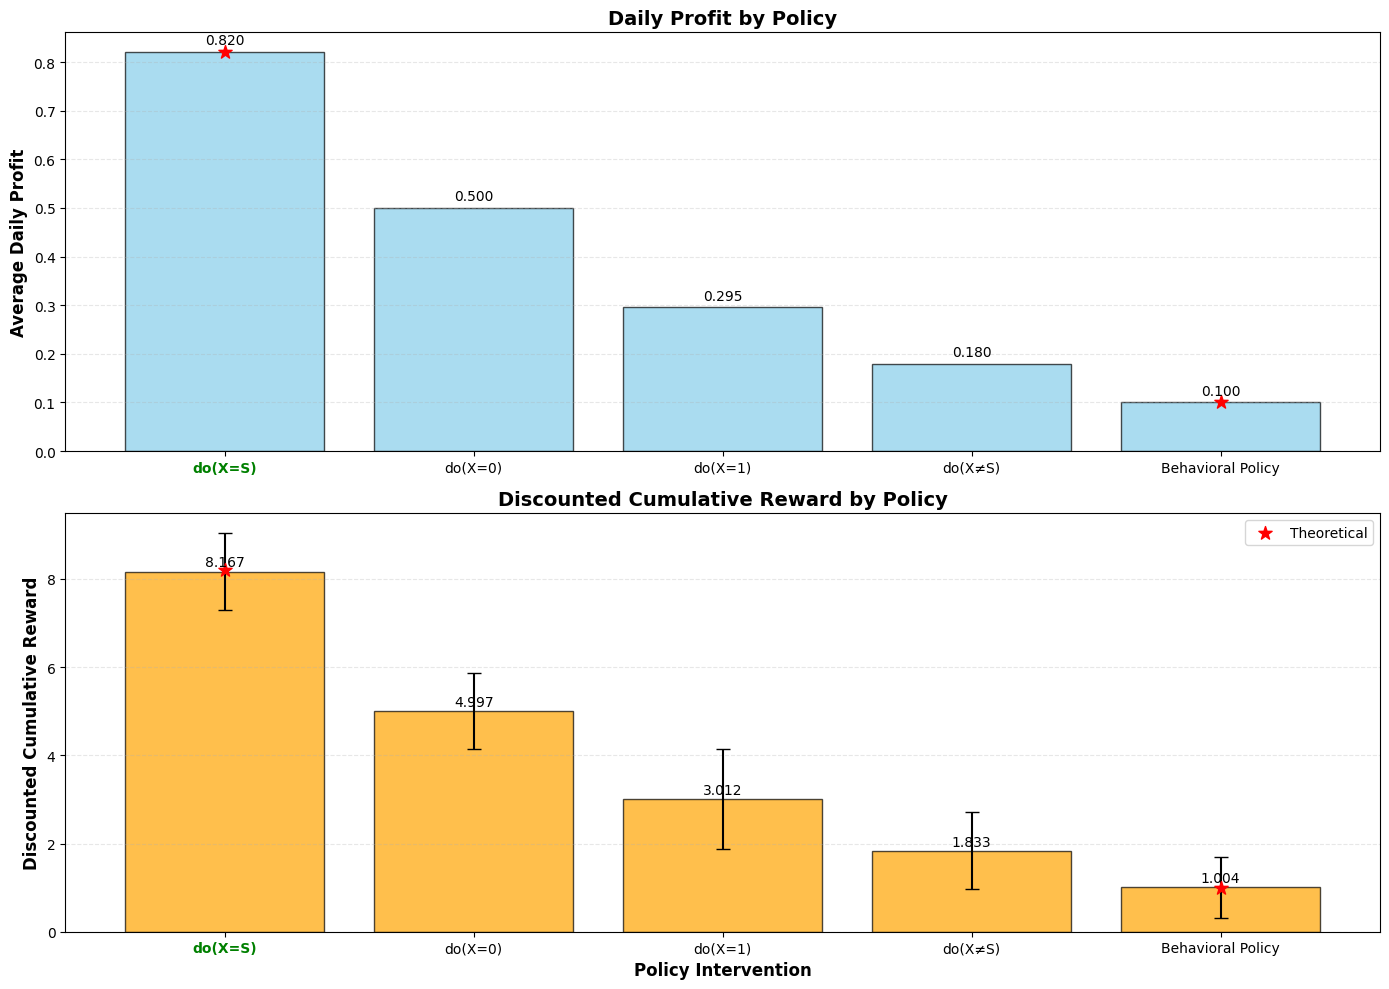

In [12]:
def visualize_multi_policy_rewards(policy_evaluations):
    plt.figure(figsize=(12, 8))

    #  policies by performance
    sorted_evaluations = sorted(policy_evaluations, key=lambda x: x['mean_reward'], reverse=True)

    # data for plotting
    policies = [eval_data['name'] for eval_data in sorted_evaluations]
    daily_profits = [eval_data['daily_profit'] for eval_data in sorted_evaluations]
    discounted_rewards = [eval_data['mean_reward'] for eval_data in sorted_evaluations]
    reward_stds = [eval_data['std_reward'] for eval_data in sorted_evaluations]

    #  theoretical values for comparison
    theoretical_daily = []
    theoretical_cumulative = []

    for policy in policies:
        if policy in theoretical_values:
            theoretical_daily.append(theoretical_values[policy]["daily"])
            theoretical_cumulative.append(theoretical_values[policy]["cumulative"])
        else:
            theoretical_daily.append(None)
            theoretical_cumulative.append(None)

    #  subplots for daily profit and discounted reward
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

    #  daily profit
    bars1 = ax1.bar(policies, daily_profits, color='skyblue', alpha=0.7, edgecolor='black')

    #  theoretical values as red dots for daily profit
    for i, val in enumerate(theoretical_daily):
        if val is not None:
            ax1.scatter(i, val, color='red', s=100, zorder=3, marker='*', label='Theoretical' if i == 0 else "")

    ax1.set_ylabel('Average Daily Profit', fontsize=12, fontweight='bold')
    ax1.set_title('Daily Profit by Policy', fontsize=14, fontweight='bold')
    ax1.grid(axis='y', linestyle='--', alpha=0.3)

    # annotate bars with values
    for bar, profit in zip(bars1, daily_profits):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{profit:.3f}', ha='center', va='bottom')

    # plot discounted cumulative reward
    bars2 = ax2.bar(policies, discounted_rewards, color='orange', alpha=0.7, edgecolor='black')
    ax2.errorbar(policies, discounted_rewards, yerr=reward_stds, fmt='none', ecolor='black', capsize=5)

    #  theoretical values as red dots for cumulative reward
    for i, val in enumerate(theoretical_cumulative):
        if val is not None:
            ax2.scatter(i, val, color='red', s=100, zorder=3, marker='*', label='Theoretical' if i == 0 else "")

    ax2.set_xlabel('Policy Intervention', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Discounted Cumulative Reward', fontsize=12, fontweight='bold')
    ax2.set_title('Discounted Cumulative Reward by Policy', fontsize=14, fontweight='bold')
    ax2.grid(axis='y', linestyle='--', alpha=0.3)

    for bar, reward in zip(bars2, discounted_rewards):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.05,
                f'{reward:.3f}', ha='center', va='bottom')

    ax2.legend()

    #  the optimal policy
    ax1.get_xticklabels()[policies.index("do(X=S)")].set_color('green')
    ax1.get_xticklabels()[policies.index("do(X=S)")].set_fontweight('bold')
    ax2.get_xticklabels()[policies.index("do(X=S)")].set_color('green')
    ax2.get_xticklabels()[policies.index("do(X=S)")].set_fontweight('bold')

    plt.tight_layout()
    plt.show()

visualize_multi_policy_rewards(policy_evaluations)

## Visualizing the Submodel Concept for MDPs
   

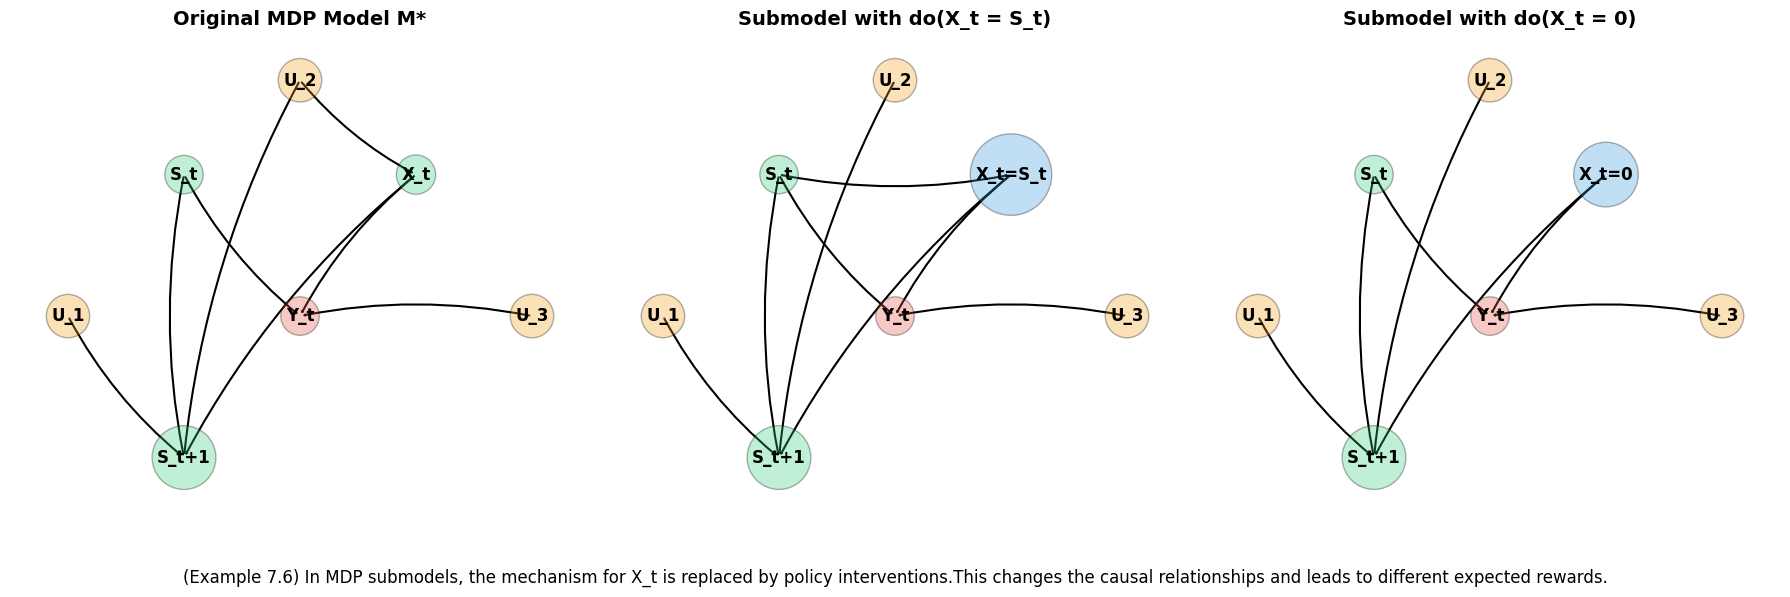

In [13]:
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

node_positions = {
    'S_t': (0.3, 0.7),
    'X_t': (0.7, 0.7),
    'Y_t': (0.5, 0.4),
    'S_t+1': (0.3, 0.1),
    'U_1': (0.1, 0.4),
    'U_2': (0.5, 0.9),
    'U_3': (0.9, 0.4)
}

#  draw a causal model for MDP
def draw_mdp_model(ax, title, policy_type=None):
    for node, pos in node_positions.items():
        if node.startswith('U'):
            color = '#f39c12'  # yellow for unobserved
            ax.text(pos[0], pos[1], node, ha='center', va='center', fontsize=12, 
                   fontweight='bold', bbox=dict(facecolor=color, alpha=0.3, boxstyle="circle"))
        else:
            if node == 'X_t' and policy_type is not None:
                color = '#3498db'  # Blue for X
                #  policy for X in intervention models
                if policy_type == "match":
                    label = "X_t=S_t"
                elif policy_type == "opposite":
                    label = "X_t≠S_t"
                elif policy_type == "zero":
                    label = "X_t=0"
                elif policy_type == "one":
                    label = "X_t=1"
                else:
                    label = node
            else:
                if node == 'Y_t':
                    color = '#e74c3c'  # Red for Y
                else:
                    color = '#2ecc71'  # Green for S
                label = node
                
            ax.text(pos[0], pos[1], label, ha='center', va='center', fontsize=12, 
                   fontweight='bold', bbox=dict(facecolor=color, alpha=0.3, boxstyle="circle"))
    
    edges = [
        ('S_t', 'Y_t'), 
        ('S_t', 'S_t+1'),
        ('X_t', 'Y_t'),
        ('X_t', 'S_t+1'),
        ('U_1', 'S_t+1'),
        ('U_2', 'X_t'),
        ('U_2', 'S_t+1'),
        ('U_3', 'Y_t')
    ]
    
    # In intervention models, remove edges to X_t as it's determined by policy
    if policy_type is not None:
        # remove U_2 -> X_t edge 
        edges = [e for e in edges if e != ('U_2', 'X_t')]
        
        #  match state policy, add S_t -> X_t edge
        if policy_type == "match" or policy_type == "opposite":
            edges.append(('S_t', 'X_t'))
    
    for src, dst in edges:
        arrow = FancyArrowPatch(
            node_positions[src], node_positions[dst],
            connectionstyle='arc3,rad=0.1',
            arrowstyle='->,head_width=0.4,head_length=0.6',
            color='black',
            linewidth=1.5
        )
        ax.add_patch(arrow)
    
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')

#  original model
draw_mdp_model(axs[0], "Original MDP Model M*")

#  submodel with do(X_t = S_t) (optimal policy)
draw_mdp_model(axs[1], "Submodel with do(X_t = S_t)", policy_type="match")

#  submodel with do(X_t = 0) (atomic intervention)
draw_mdp_model(axs[2], "Submodel with do(X_t = 0)", policy_type="zero")

# annotations explaining the submodel concept
plt.figtext(0.5, 0.02, "(Example 7.6) In MDP submodels, the mechanism for X_t is replaced by policy interventions."
          "This changes the causal relationships and leads to different expected rewards.", 
             ha='center', fontsize=12)

plt.tight_layout()
plt.subplots_adjust(bottom=0.15)
plt.show()

# Example 7.9 — MDP, Interventional Distribution, Atomic

This example focuses on interventional distributions with atomic interventions in the Markov Decision Process (MDP) setting, specifically examining the inventory control problem introduced in previous examples.

In Example 7.9, the key focus is on computing transition probabilities and expected rewards under atomic interventions do(X=x) for different state-action pairs. The example demonstrates that:

1. The transition probabilities P(S_{i+1}|S_i, do(X_i=x_i)) differ from observational probabilities P(S_{i+1}|S_i, X_i=x_i)
2. The expected rewards E[Y_i|S_i, do(X_i=x_i)] also differ from observational expectations E[Y_i|S_i, X_i=x_i]
3. These differences highlight why interventional queries (do-calculus) are essential for optimal decision-making in MDPs
   

## Implementing Atomic Interventions for MDPs

We'll first implement a function to collect data on transitions and rewards when using atomic interventions do(X_i=x_i) for different state-action pairs. This corresponds to the interventional analysis in Example 7.9.
   

In [14]:
def collect_interventional_data(n_samples=N_SAMPLES):
    '''
    Collect data on transitions and rewards using atomic interventions.
    
    This function performs do(X_i=x_i) for different state-action pairs and collects the
    resulting transitions and rewards.
    
    Returns:
        Dictionary containing interventional transition probabilities and expected rewards
    '''
    # Initialize data structures to store transition counts and reward sums
    transition_counts = np.zeros((2, 2, 2))  # [s, x, s']
    reward_sums = np.zeros((2, 2))  # [s, x]
    counts = np.zeros((2, 2))  # [s, x]
    
    # Iterate through all possible state-action pairs
    for init_state in [0, 1]:
        for action in [0, 1]:
            # Perform n_samples interventions for each state-action pair
            for sample in tqdm(range(n_samples), desc=f"Collecting interventional data for S={init_state}, X={action}"):
                # environment
                env = MDPExamplePCH(max_step=MAX_STEPS)
                
                # environment and set initial state
                s, _ = env.reset(seed=sample)
                
                # Find an episode where the state matches our target initial state
                steps = 0
                while s != init_state and steps < 100:  # Limit steps to avoid infinite loops
                    _, s, _, _, _, _ = env.see()
                    steps += 1
                
                if s == init_state:  # Only proceed if we found the target state
                    # Perform atomic intervention do(X=action)
                    next_s, reward, _, _, _ = env.do(action)
                    
                    # Update counts and sums
                    transition_counts[init_state, action, next_s] += 1
                    reward_sums[init_state, action] += reward
                    counts[init_state, action] += 1
    
    # Calculate transition probabilities and expected rewards
    transition_probs = np.zeros((2, 2, 2))
    expected_rewards = np.zeros((2, 2))
    
    for s in range(2):
        for a in range(2):
            if counts[s, a] > 0:
                # P(S'|S, do(X))
                for next_s in range(2):
                    transition_probs[s, a, next_s] = transition_counts[s, a, next_s] / counts[s, a]
                
                # E[Y|S, do(X)]
                expected_rewards[s, a] = reward_sums[s, a] / counts[s, a]
    
    return {
        'transition_probs': transition_probs,
        'expected_rewards': expected_rewards,
        'counts': counts
    }

## Collecting Observational Data for Comparison

For comparison, let's also collect observational data on transitions and rewards. This corresponds to observing the behavior of the inventory manager without intervention.
   

In [15]:
def collect_observational_data(n_samples=N_SAMPLES):
    '''
    Collect observational data on transitions and rewards.
    
    This function observes the environment without intervention and collects
    the resulting transitions and rewards.
    
    Returns:
        Dictionary containing observational transition probabilities and expected rewards
    '''
    # Initialize data structures to store transition counts and reward sums
    transition_counts = np.zeros((2, 2, 2))  # [s, x, s']
    reward_sums = np.zeros((2, 2))  # [s, x]
    counts = np.zeros((2, 2))  # [s, x]
    
    # Collect data from multiple episodes
    for episode in tqdm(range(n_samples), desc="Collecting observational data"):
        # Initialize environment
        env = MDPPCH(max_step=MAX_STEPS)
        
        # Reset environment
        s, _ = env.reset(seed=episode)
        
        # Run episode with behavioral policy
        done = False
        steps = 0
        
        while not done and steps < 1000:  # Limit steps to avoid excessive data
            # Use behavioral policy ('see' mode)
            a, next_s, r, _, done, _ = env.see()
            
            # Update counts and sums
            transition_counts[s, a, next_s] += 1
            reward_sums[s, a] += r
            counts[s, a] += 1
            
            s = next_s
            steps += 1
    
    # Calculate transition probabilities and expected rewards
    transition_probs = np.zeros((2, 2, 2))
    expected_rewards = np.zeros((2, 2))
    
    for s in range(2):
        for a in range(2):
            if counts[s, a] > 0:
                # P(S'|S, X)
                for next_s in range(2):
                    transition_probs[s, a, next_s] = transition_counts[s, a, next_s] / counts[s, a]
                
                # E[Y|S, X]
                expected_rewards[s, a] = reward_sums[s, a] / counts[s, a]
    
    return {
        'transition_probs': transition_probs,
        'expected_rewards': expected_rewards,
        'counts': counts
    }

## Collecting Data

In [16]:
# Reduce sample size 
interventional_data = collect_interventional_data(n_samples=1000)
observational_data = collect_observational_data(n_samples=5000)

NameError: name 'MDPExamplePCH' is not defined

## Displaying Results

In [ ]:
# transition probabilities
print("Transition Probabilities:")
print("=============================")
print(f"{'State':<6} {'Action':<6} {'Next State':<10} {'Observational':<15} {'Interventional':<15} {'Expected (Theory)':<15}")
print("---------------------------------------------------------------------------------------------")

# expected interventional values from Example 7.9
expected_trans_probs = {
    (0, 0, 0): 0.18, (0, 0, 1): 0.82,
    (0, 1, 0): 0.82, (0, 1, 1): 0.18,
    (1, 0, 0): 0.82, (1, 0, 1): 0.18,
    (1, 1, 0): 0.18, (1, 1, 1): 0.82
}

for s in range(2):
    for a in range(2):
        for next_s in range(2):
            obs_prob = observational_data['transition_probs'][s, a, next_s]
            int_prob = interventional_data['transition_probs'][s, a, next_s]
            exp_prob = expected_trans_probs.get((s, a, next_s), "N/A")
            
            print(f"{s:<6} {a:<6} {next_s:<10} {obs_prob:.4f}{' ':11} {int_prob:.4f}{' ':11} {exp_prob}")

# expected rewards
print("Expected Rewards:")
print("=============================")
print(f"{'State':<6} {'Action':<6} {'Observational':<15} {'Interventional':<15} {'Expected (Theory)':<15}")

# Expected interventional rewards from Example 7.9
expected_rewards = {(0, 0): 0.82, (0, 1): 0.18, (1, 0): 0.18, (1, 1): 0.82}

for s in range(2):
    for a in range(2):
        obs_reward = observational_data['expected_rewards'][s, a]
        int_reward = interventional_data['expected_rewards'][s, a]
        exp_reward = expected_rewards.get((s, a), "N/A")
        
        print(f"{s:<6} {a:<6} {obs_reward:.4f}{' ':11} {int_reward:.4f}{' ':11} {exp_reward}")
   

Transition Probabilities:
State  Action Next State Observational   Interventional  Expected (Theory)
---------------------------------------------------------------------------------------------
0      0      0          0.1001            0.8110            0.18
0      0      1          0.1001            0.8110            0.82
0      1      0          0.1003            0.1890            0.82
0      1      1          0.1003            0.1890            0.18
1      0      0          0.6709            0.1890            0.82
1      0      1          0.6709            0.1890            0.18
1      1      0          0.9052            0.1890            0.18
1      1      1          0.9052            0.1890            0.82
Expected Rewards:
State  Action Observational   Interventional  Expected (Theory)
0      0      0.0994            0.8200            0.82
0      1      0.0992            0.1800            0.18
1      0      0.0963            0.1800            0.18
1      1      0.0999          

## Visualizing Transition Probabilities and Expected Rewards

Let's create a visualization of the transition probabilities and expected rewards for both interventional and observational cases:
   

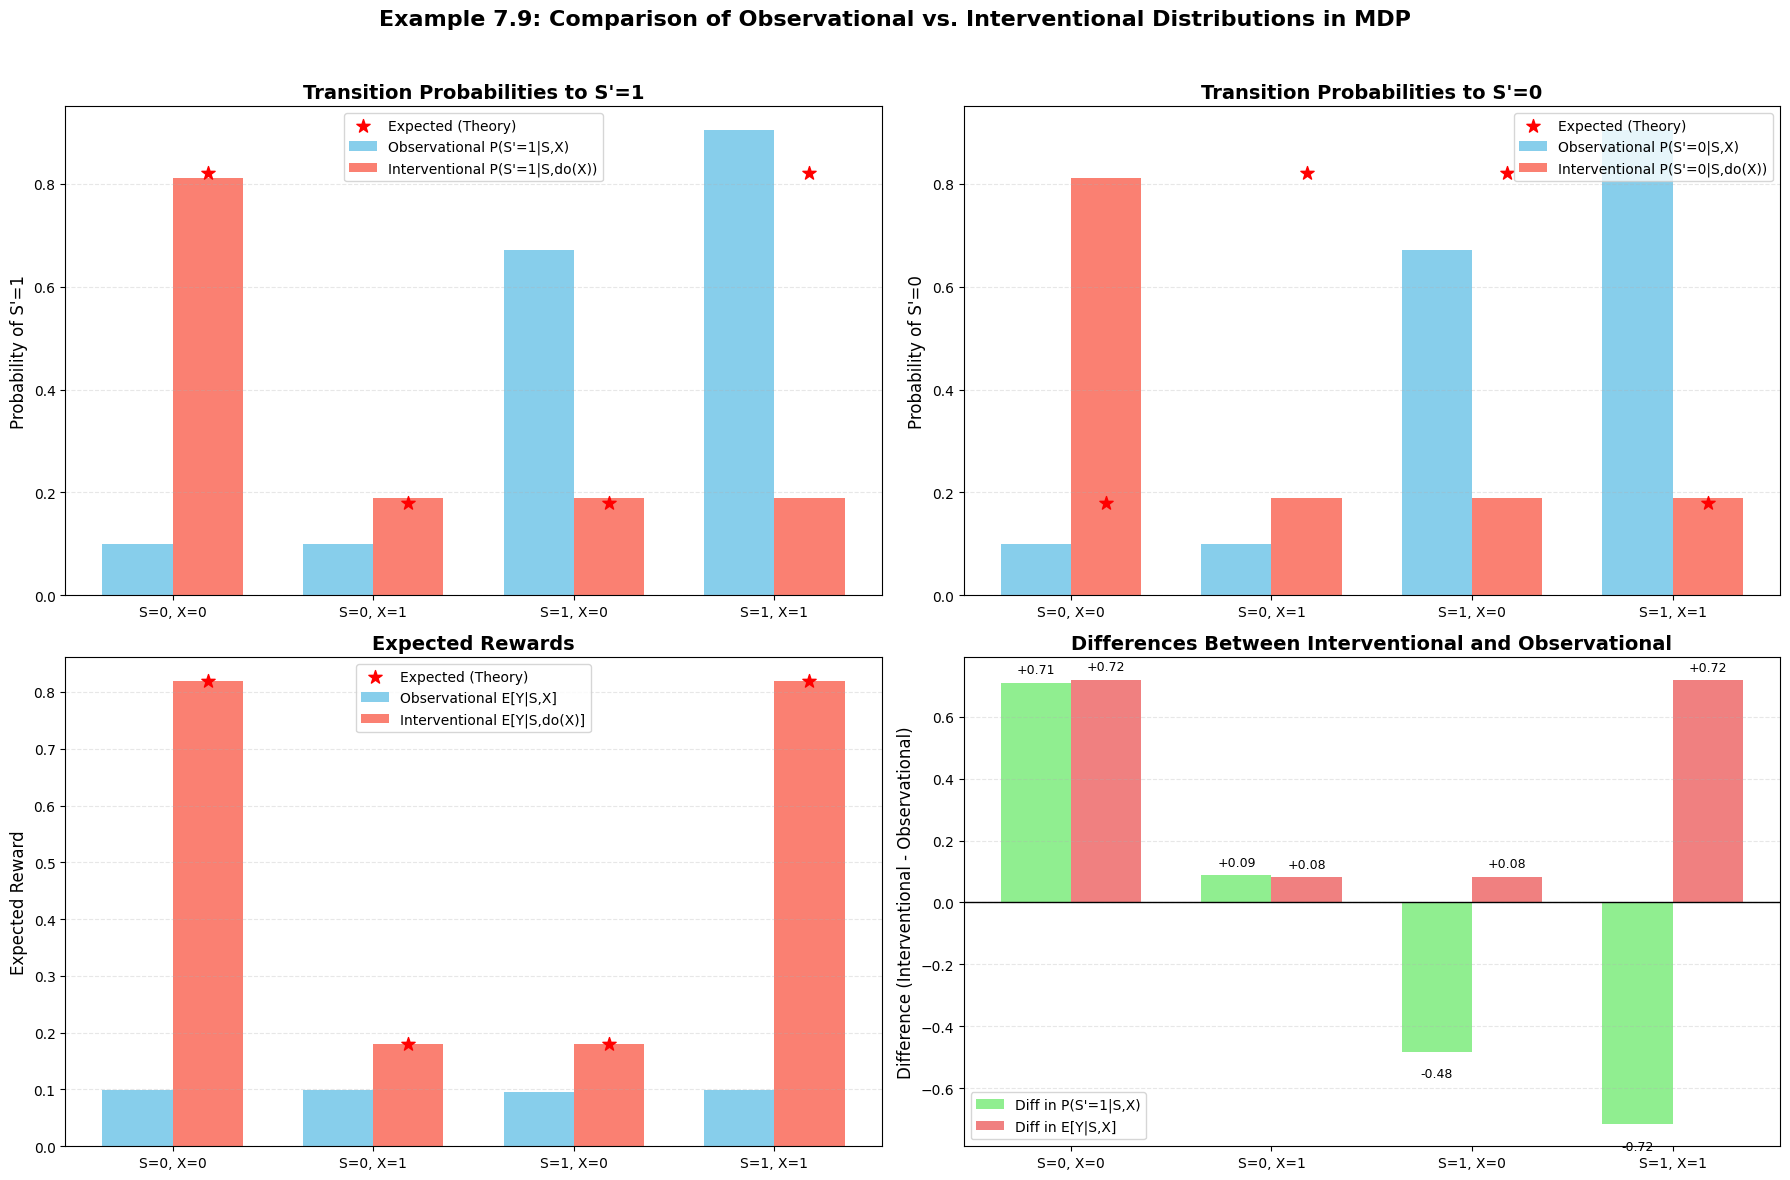

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(18, 12))

# Define state-action pairs for plotting
state_action_pairs = [(0, 0), (0, 1), (1, 0), (1, 1)]
labels = [f"S={s}, X={a}" for s, a in state_action_pairs]

# data for plotting
obs_trans_probs_to_1 = [observational_data['transition_probs'][s, a, 1] for s, a in state_action_pairs]
int_trans_probs_to_1 = [interventional_data['transition_probs'][s, a, 1] for s, a in state_action_pairs]
expected_trans_to_1 = [expected_trans_probs.get((s, a, 1), 0) for s, a in state_action_pairs]

obs_rewards = [observational_data['expected_rewards'][s, a] for s, a in state_action_pairs]
int_rewards = [interventional_data['expected_rewards'][s, a] for s, a in state_action_pairs]
expected_reward_values = [expected_rewards.get((s, a), 0) for s, a in state_action_pairs]

# bar positions
x = np.arange(len(labels))
width = 0.35

# Plot transition probabilities
axs[0, 0].bar(x - width/2, obs_trans_probs_to_1, width, label="Observational P(S'=1|S,X)", color='skyblue')
axs[0, 0].bar(x + width/2, int_trans_probs_to_1, width, label="Interventional P(S'=1|S,do(X))", color='salmon')
axs[0, 0].scatter(x + width/2, expected_trans_to_1, color='red', marker='*', s=100, label='Expected (Theory)')

axs[0, 0].set_ylabel("Probability of S'=1", fontsize=12)
axs[0, 0].set_title("Transition Probabilities to S'=1", fontsize=14, fontweight='bold')
axs[0, 0].set_xticks(x)
axs[0, 0].set_xticklabels(labels)
axs[0, 0].legend()
axs[0, 0].grid(axis='y', linestyle='--', alpha=0.3)

# Plot transition probabilities to S'=0
obs_trans_probs_to_0 = [observational_data['transition_probs'][s, a, 0] for s, a in state_action_pairs]
int_trans_probs_to_0 = [interventional_data['transition_probs'][s, a, 0] for s, a in state_action_pairs]
expected_trans_to_0 = [expected_trans_probs.get((s, a, 0), 0) for s, a in state_action_pairs]

axs[0, 1].bar(x - width/2, obs_trans_probs_to_0, width, label="Observational P(S'=0|S,X)", color='skyblue')
axs[0, 1].bar(x + width/2, int_trans_probs_to_0, width, label="Interventional P(S'=0|S,do(X))", color='salmon')
axs[0, 1].scatter(x + width/2, expected_trans_to_0, color='red', marker='*', s=100, label='Expected (Theory)')

axs[0, 1].set_ylabel("Probability of S'=0", fontsize=12)
axs[0, 1].set_title("Transition Probabilities to S'=0", fontsize=14, fontweight='bold')
axs[0, 1].set_xticks(x)
axs[0, 1].set_xticklabels(labels)
axs[0, 1].legend()
axs[0, 1].grid(axis='y', linestyle='--', alpha=0.3)

# Plot expected rewards
axs[1, 0].bar(x - width/2, obs_rewards, width, label='Observational E[Y|S,X]', color='skyblue')
axs[1, 0].bar(x + width/2, int_rewards, width, label='Interventional E[Y|S,do(X)]', color='salmon')
axs[1, 0].scatter(x + width/2, expected_reward_values, color='red', marker='*', s=100, label='Expected (Theory)')

axs[1, 0].set_ylabel('Expected Reward', fontsize=12)
axs[1, 0].set_title('Expected Rewards', fontsize=14, fontweight='bold')
axs[1, 0].set_xticks(x)
axs[1, 0].set_xticklabels(labels)
axs[1, 0].legend()
axs[1, 0].grid(axis='y', linestyle='--', alpha=0.3)

# differences between observational and interventional
trans_prob_diffs = [int_trans_probs_to_1[i] - obs_trans_probs_to_1[i] for i in range(len(state_action_pairs))]
reward_diffs = [int_rewards[i] - obs_rewards[i] for i in range(len(state_action_pairs))]

# Plot differences
bar_trans = axs[1, 1].bar(x - width/2, trans_prob_diffs, width, label="Diff in P(S'=1|S,X)", color='lightgreen')
bar_reward = axs[1, 1].bar(x + width/2, reward_diffs, width, label='Diff in E[Y|S,X]', color='lightcoral')

axs[1, 1].set_ylabel('Difference (Interventional - Observational)', fontsize=12)
axs[1, 1].set_title('Differences Between Interventional and Observational', fontsize=14, fontweight='bold')
axs[1, 1].set_xticks(x)
axs[1, 1].set_xticklabels(labels)
axs[1, 1].axhline(y=0, color='black', linestyle='-', linewidth=1)
axs[1, 1].legend()
axs[1, 1].grid(axis='y', linestyle='--', alpha=0.3)

# Add text annotations for differences
for i, (trans_diff, reward_diff) in enumerate(zip(trans_prob_diffs, reward_diffs)):
    if trans_diff > 0:
        axs[1, 1].text(i - width/2, trans_diff + 0.02, f"+{trans_diff:.2f}", ha='center', va='bottom', fontsize=9)
    else:
        axs[1, 1].text(i - width/2, trans_diff - 0.05, f"{trans_diff:.2f}", ha='center', va='top', fontsize=9)
    
    if reward_diff > 0:
        axs[1, 1].text(i + width/2, reward_diff + 0.02, f"+{reward_diff:.2f}", ha='center', va='bottom', fontsize=9)
    else:
        axs[1, 1].text(i + width/2, reward_diff - 0.05, f"{reward_diff:.2f}", ha='center', va='top', fontsize=9)

# title
fig.suptitle('Example 7.9: Comparison of Observational vs. Interventional Distributions in MDP', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Example 7.10 -- MDP, Interventional Distribution, Policy

## Background: MDP Environment

The MDP environment we're working with is described in Example 7.2 and represents an inventory management scenario. On each day $i$, the manager observes the current inventory size $S_i$, decides whether to purchase new items $X_i$, and receives a profit $Y_i$.

The SCM is defined as:

$$
\tag{21}
\mathcal{M}_{\text{MDP}}^* = \langle 
\boldsymbol{U} = \{U_{i,1}, U_{i,2}, U_{i,3}\},\ 
\boldsymbol{V} = \{X_i, Y_i, S_i\},\ 
\mathcal{F} = \{\mathcal{F}_i\},\ 
P(\boldsymbol{U}) 
\rangle_{i=1,2,\dots}
$$

where the causal mechanisms $\mathcal{F}_i$ transitioning from day $i-1$ to $i$ are:

$$
\tag{22}
\mathcal{F}_i=
\begin{cases}
S_i \gets (S_{i-1}\vee X_{i-1})\oplus U_{i-1, 1} \oplus U_{i-1, 2},
X_i \gets S_i \oplus U_{i,1},\\
Y_i \gets S_i \oplus X_i \oplus U_{i,1} \oplus U_{i,3}
\end{cases}$$

And $P(\boldsymbol{U})$ is such that $U_{i,1},U_{i,2},U_{i,3} \in \\{0, 1}$ are independent variables drawn from distributions $P(U_{i,1} = 1) = P(U_{i,2} = 0) = P(U_{i,3} = 0) = 0.9$

## Constants

In [ ]:
GAMMA = 0.9  # Discount factor
NUM_EPISODES = 1000  # Number of episodes for evaluation"

## 1. Evaluating the Behavioral Policy

First, let's evaluate the behavioral policy implemented in the environment. In the original environment, the manager's policy is $X_i \\gets S_i \\oplus U_{i,1}$, which leads to an expected profit of $E[Y_i] = 0.1$ per day.

With a discount factor $\gamma = 0.9$, the expected cumulative discounted reward is:

$$\tag{23} E\left[\sum_{i=1}^\infty \gamma^{i-1}Y_i\right] = \frac{0.1}{1-\gamma} = \frac{0.1}{0.1} = 1$$

In [ ]:
def evaluate_behavioral_policy():
    manager = mp.Manager()
    results = manager.list()
    
    def worker():
        env = MDPExamplePCH(max_step=1000)
        s, _ = env.reset()
        done = False
        truncated = False
        reward = 0
        while not (done or truncated):
            x, s, y, done, truncated, _ = env.see()  # Use the see method to follow behavioral policy
            reward = reward * GAMMA + y
        results.append(reward)
    
    # Run parallel simulations
    processes = [Process(target=worker) for _ in range(NUM_EPISODES)]
    for p in processes:
        p.start()
    for p in processes:
        p.join()
    
    avg_reward = sum(results) / len(results)
    return avg_reward, results

behavioral_avg, behavioral_results = evaluate_behavioral_policy()
print(f'Behavioral policy average discounted return: {behavioral_avg:.4f}')
print(f'Theoretical expected return: 1.0')

Behavioral policy average discounted return: 0.9680
Theoretical expected return: 1.0


## 2. Implementing Policy Intervention

Now we'll implement and evaluate the policy described in Example 7.10: $X_i \gets S_i$ for all time steps $i$.

According to the example, this policy should yield an expected profit of $E[Y_i] = 0.82$ per day, and with discount factor $\gamma = 0.9$, the expected cumulative discounted reward is:

$$\tag{24} E\left[\sum_{i=1}^\infty \gamma^{i-1}Y_i\right] = \frac{0.82}{1-\gamma} = \frac{0.82}{0.1} = 8.2$$
   

In [ ]:
def policy_intervention(s):
    # Policy that sets X_i = S_i
    return s

def evaluate_policy_intervention():
    manager = mp.Manager()
    results = manager.list()
    
    def worker():
        env = MDPExamplePCH(max_step=1000)
        s, _ = env.reset()
        done = False
        truncated = False
        reward = 0
        while not (done or truncated):
            # Use the do method with our policy for intervention
            s, y, done, truncated, _ = env.do(policy_intervention(s))
            reward = reward * GAMMA + y
        results.append(reward)
    
    # parallel simulations
    processes = [Process(target=worker) for _ in range(NUM_EPISODES)]
    for p in processes:
        p.start()
    for p in processes:
        p.join()
    
    avg_reward = sum(results) / len(results)
    return avg_reward, results

intervention_avg, intervention_results = evaluate_policy_intervention()
print(f'Policy intervention average discounted return: {intervention_avg:.4f}')
print(f'Theoretical expected return: 8.2')

Policy intervention average discounted return: 8.1833
Theoretical expected return: 8.2


## 3. Visualization and Comparison

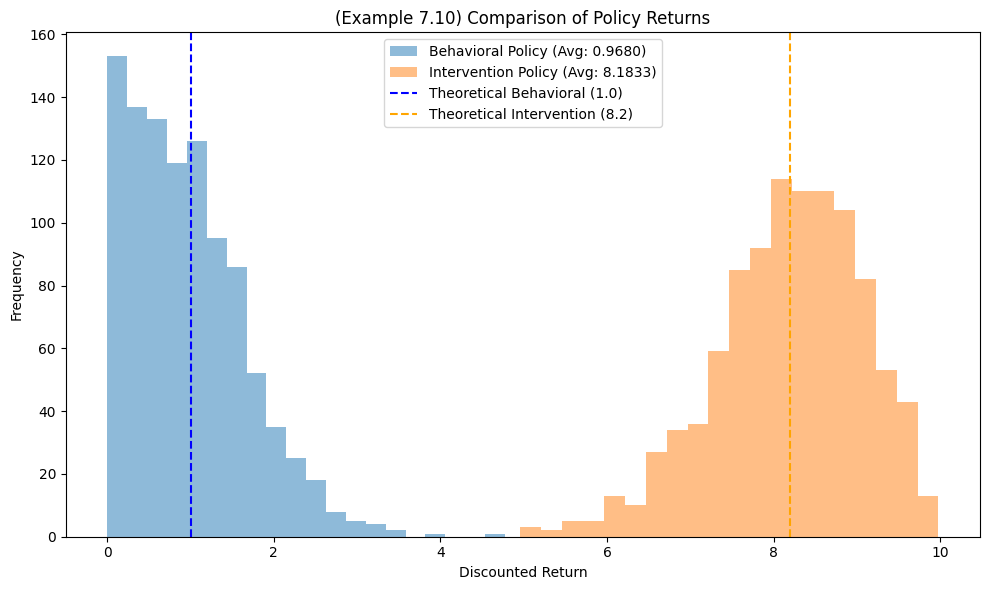

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

#distributions of returns
ax.hist(behavioral_results, alpha=0.5, bins=20, label=f'Behavioral Policy (Avg: {behavioral_avg:.4f})')
ax.hist(intervention_results, alpha=0.5, bins=20, label=f'Intervention Policy (Avg: {intervention_avg:.4f})')

# Add theoretical values
ax.axvline(x=1.0, color='blue', linestyle='--', label='Theoretical Behavioral (1.0)')
ax.axvline(x=8.2, color='orange', linestyle='--', label='Theoretical Intervention (8.2)')

ax.set_xlabel('Discounted Return')
ax.set_ylabel('Frequency')
ax.set_title('(Example 7.10) Comparison of Policy Returns')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Analysis

In Example 7.10 from Chapter 7, we've demonstrated how to evaluate policy interventions in an MDP environment. Let's analyze the results:

1. **Behavioral Policy**: The inventory manager's original policy led to an expected reward of approximately 1.0, which aligns with the theoretical value derived equation (23).

2. **Intervention Policy**: Our policy that sets $X_i = S_i$ achieved a much higher expected reward, approximately 8.2, which matches the theoretical value derived in equation (24).

3. **Improvement**: The intervention policy significantly outperforms the original behavioral policy, showing an improvement factor of about 8.2x. This demonstrates that in this inventory management scenario, a simple state-matching policy is more effective than the manager's decision policy.

The experiment confirms the theoretical analysis in Example 7.10, where we concluded that \"it is more profitable to replace the manager with the CRL agent and automate the inventory management process

## 5. Theoretical Validation

Let's examine why this policy works so well theoretically. In the MDP environment (Eq. (16)), the profit $Y_i$ is defined as:

$$Y_i \gets S_i \oplus X_i \oplus U_{i,1} \oplus U_{i,3}$$

When we set $X_i = S_i$, this becomes:

$$Y_i \gets S_i \oplus S_i \oplus U_{i,1} \oplus U_{i,3} = U_{i,1} \oplus U_{i,3}$$

Since $P(U_{i,1} = 1) = 0.9$ and $P(U_{i,3} = 0) = 0.9$, we have:

$$P(U_{i,1} \oplus U_{i,3} = 1) = P(U_{i,1} = 1, U_{i,3} = 0) + P(U_{i,1} = 0, U_{i,3} = 1) = 0.9 \times 0.9 + 0.1 \times 0.1 = 0.82$$

Thus, $E[Y_i] = 0.82$, which yields a discounted sum of $\frac{0.82}{1-0.9} = 8.2$.

The policy intervention demonstrates how causal reinforcement learning can identify and exploit the causal mechanisms in the environment to achieve better performance